In [71]:
import sys
!{sys.executable} -m pip install requests



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests

def get_content(article_name):
    wiki_url = "https://en.wikipedia.org/w/api.php"
    params = {
        'action': 'query',
        'titles': article_name,
        'prop': 'revisions',
        'rvprop': 'content',
        'rvslots': 'main',
        'format': 'json',
        "formatversion": 2,
    }
    
    headers = {
        'User-Agent': 'MyWikiClient/1.0 (your_email@example.com)'
    }
    response = requests.get(wiki_url, params=params, headers=headers)
    print("Status code:", response.status_code)
    
    try:
        data = response.json()
    except ValueError:
        print("Response is not valid JSON....")
        print(response.text[:200])
        raise
    
  
    return data
    # return response.status_code, response.json()


In [3]:
import re
def merge_contents(data):
    try:
        pages = data['query']['pages']
        info_list = []
        for page in pages:
            revisions = page.get('revisions', [])
            for revision in revisions:
                content = revision['slots']['main']['content']

                content = re.sub(r'{{cite[^}]+}}', '', content, flags=re.IGNORECASE)

                content = re.sub(r'\[http[^\]]+\]', '', content)

                content = re.sub(r'\[\[([^\]|]+\|)?([^\]]+)\]\]', r'\2', content)

                content = re.sub(r'\[\[', '', content)
                content = re.sub(r'\]\]', '', content)
                
                info_list.append(content)
        return " ".join(info_list)
    except:
        return ""


In [4]:
def tokenize(content):
    splitter_chars = [" ", "\n", "|", "=", "'", "[", "]", "<", ">", ",", ".", "-", "/", 
                      "\"", "(", ")", ";", "{", "}", ":", "&", "_", "*", "\t", "%", "?", "!"]
    word_list = []
    curr_word = ""
        
    for ch in content:
        if ch in splitter_chars:
            if curr_word:
                word_list.append(curr_word)
                curr_word = ""
        else:
            curr_word += ch
                
    if curr_word:
        word_list.append(curr_word)
        
    return word_list


In [5]:
def lower_collection(collection):
    lowercase_list = []
    
    for word in collection:
        lowercase_word = word.lower()
        lowercase_list.append(lowercase_word)
    
    return lowercase_list

In [6]:
def count_frequency(collection):
    word_freq = {}
    
    for word in collection:
        if word in word_freq:
            word_freq[word] += 1
        else:
            word_freq[word] = 1
    
    return word_freq

In [7]:
def print_most_frequent(frequencies, n):
    most_freq = list(frequencies.items())

    most_freq.sort(key=lambda pair: pair[1], reverse=True)
    
    for word, count in most_freq[:n]:
        print(word, " : ", count)


In [8]:
import matplotlib.pyplot as plt

def visualize_word_freq(frequencies, n):
    most_freq = sorted(frequencies.items(), key=lambda pair: pair[1], reverse=True)[:n]
    words = [item[0] for item in most_freq]
    word_count = [item[1] for item in most_freq]
    
    plt.figure(figsize=(12, 6))
    # plt.bar(words, word_count, color = "blue")
    plt.barh(words[::-1], word_count[::-1], color='blue')
    plt.xlabel('Word Count', fontsize=10, fontweight='bold')
    plt.ylabel('Words', fontsize=10, fontweight='bold')
    plt.title(f'Top {n} Most Frequent Words', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [9]:
def remove_stop_words(words, stop_words):
    
    filler_set = set(stop_words)
    filtered_words = [w for w in words if w not in filler_set]
    return filtered_words

Wiki Article :
Status code: 200
the  :  235
of  :  120
ozone  :  111
in  :  80
and  :  80
ref  :  67
to  :  66
is  :  43
a  :  39
layer  :  37


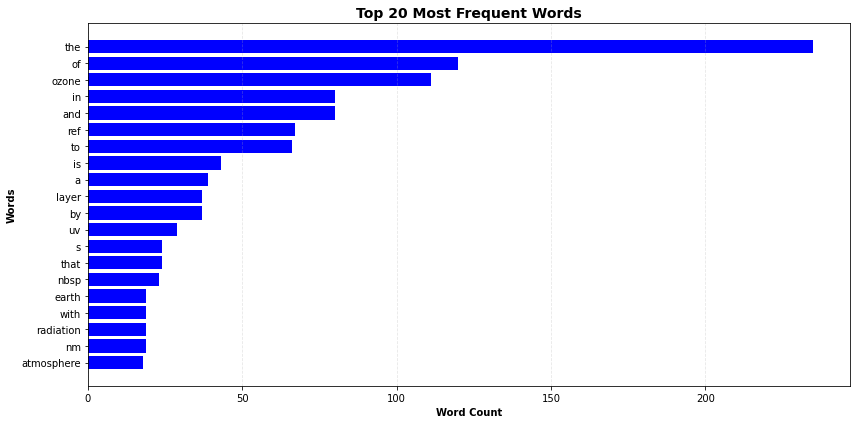

ozone  :  111
layer  :  37
uv  :  29
earth  :  19
radiation  :  19
nm  :  19
atmosphere  :  18
ultraviolet  :  16
sub  :  16
stratosphere  :  14
depletion  :  14
surface  :  12
oxygen  :  12
light  :  9
skin  :  9
percent  :  7
band  :  6
above  :  6
damage  :  6
united  :  6
air  :  6
circulation  :  6
latitudes  :  6
climate  :  6
change  :  6
countries  :  6
date  :  5
sun  :  5
high  :  5
other  :  5


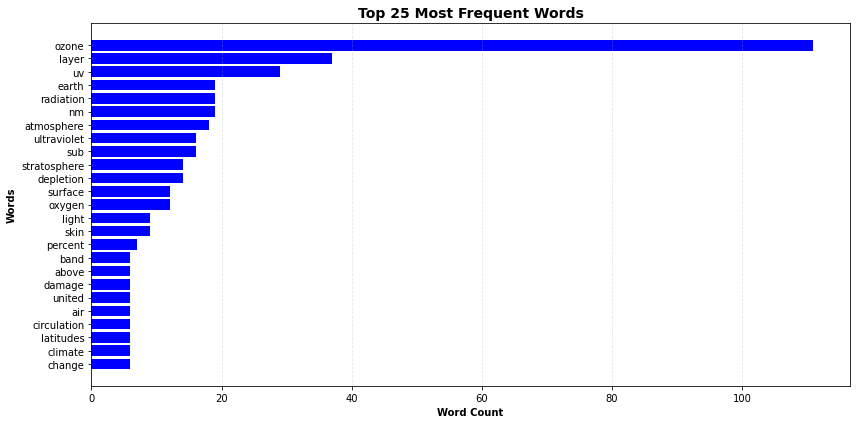

In [11]:
if __name__ == "__main__":
    print("Wiki Article :")
    data = get_content("Ozone_layer")
    
    # print(data)
    merge_content = merge_contents(data)
    # print(merge_content)

    collection = tokenize(merge_content)
    # print("Extracted words: ")
    # print(collection)

    lower_case_word_collection = lower_collection(collection)
    # print(lower_case_word_collection)

    frequencies = count_frequency(lower_case_word_collection)
    # print(frequencies)

    print_most_frequent(frequencies, 10)
    
    visualize_word_freq(frequencies, 20)
    
    stop_words = ["the", "a", "of", "in", "to", "about", "and", "ref", "is",
                  "by", "s", "that", "with", "nbsp", "from", "at", "was",
                 "are", "for", "as", "it", "be", "name", "which", "these", "have", "on",
                 "its", "into", "this", "has", "than", "more", "can", "than", "or",
                 "not", "because", "o", "an", "2", "all", "thumb", "over", "out", "c", "being",
                 "b", "cfcs", "also", "levels", "but", "were", "most", "where", "been", "3"]
    filtered_words = remove_stop_words(lower_case_word_collection, stop_words)
    
    frequencies = count_frequency(filtered_words)
    
    print("------ After Filtering")
    
    print_most_frequent(frequencies, 30)
    visualize_word_freq(frequencies,25)
    
    

    pass